In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pyDOE2 import lhs
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from scipy.interpolate import Rbf

print("All imports successful!")
print(f"Using scipy's Rbf interpolator instead of RBFInterpolant")

All imports successful!
Using scipy's Rbf interpolator instead of RBFInterpolant


In [13]:
def rosenbrock(x1, x2):
    """
    The Rosenbrock function - a classic surrogate modeling benchmark.
    
    Known for its narrow, curved valley that runs along x2 = x1²
    Easy to find the valley, hard to follow it precisely.
    
    Inputs: x1 in [-2, 2], x2 in [-1, 3]
    Global minimum at (1, 1) where f = 0
    """
    term1 = (1 - x1)**2
    term2 = 100 * (x2 - x1**2)**2
    return term1 + term2

# Sanity check at known points
print("Rosenbrock function checks:")
print(f"  At (1, 1)  = {rosenbrock(1, 1):.1f}  ← global minimum, should be 0")
print(f"  At (0, 0)  = {rosenbrock(0, 0):.1f}  ← should be 1")
print(f"  At (-1, 1) = {rosenbrock(-1, 1):.1f}  ← should be 4")
print(f"  At (2, 2)  = {rosenbrock(2, 2):.1f}  ← should be 401")
print()
print("Input ranges:")
print("  x1: [-2, 2]")
print("  x2: [-1, 3]")


Rosenbrock function checks:
  At (1, 1)  = 0.0  ← global minimum, should be 0
  At (0, 0)  = 1.0  ← should be 1
  At (-1, 1) = 4.0  ← should be 4
  At (2, 2)  = 401.0  ← should be 401

Input ranges:
  x1: [-2, 2]
  x2: [-1, 3]


In [14]:
np.random.seed(42)
n_samples = 40

# Latin Hypercube Sampling
lhs_samples = lhs(2, samples=n_samples, criterion='maximin')

# Scale to input ranges
X_train = np.zeros((n_samples, 2))
X_train[:, 0] = lhs_samples[:, 0] * 4 - 2   # x1: [-2, 2]
X_train[:, 1] = lhs_samples[:, 1] * 4 - 1   # x2: [-1, 3]

# Evaluate true function at training points
y_train = np.array([rosenbrock(X_train[i,0], X_train[i,1])
                    for i in range(n_samples)])

# 500 random test points - never seen during training
n_test = 500
X_test = np.zeros((n_test, 2))
X_test[:, 0] = np.random.uniform(-2, 2, n_test)
X_test[:, 1] = np.random.uniform(-1, 3, n_test)

y_test = np.array([rosenbrock(X_test[i,0], X_test[i,1])
                   for i in range(n_test)])

print(f"Training points : {X_train.shape}")
print(f"Test points     : {X_test.shape}")
print(f"Training output range: {y_train.min():.2f} to {y_train.max():.2f}")
print(f"Test output range    : {y_test.min():.2f} to {y_test.max():.2f}")

Training points : (40, 2)
Test points     : (500, 2)
Training output range: 0.82 to 934.45
Test output range    : 0.13 to 2258.26


In [15]:
# Scale inputs for GP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}

# ── 1. Response Surface Model (RSM) ──────────────────────
start = time.time()

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

rsm = LinearRegression()
rsm.fit(X_train_poly, y_train)
rsm_train_time = time.time() - start

start = time.time()
y_pred_rsm = rsm.predict(X_test_poly)
rsm_pred_time = time.time() - start

results['RSM'] = {
    'y_pred'     : y_pred_rsm,
    'train_time' : rsm_train_time,
    'pred_time'  : rsm_pred_time
}
print(f"RSM trained in {rsm_train_time:.4f}s")

# ── 2. Gaussian Process ───────────────────────────────────
start = time.time()

kernel = C(1.0) * RBF(length_scale=[1.0, 1.0])
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True,
    alpha=1e-6
)
gp.fit(X_train_scaled, y_train)
gp_train_time = time.time() - start

start = time.time()
y_pred_gp, y_std_gp = gp.predict(X_test_scaled, return_std=True)
gp_pred_time = time.time() - start

results['GP'] = {
    'y_pred'     : y_pred_gp,
    'y_std'      : y_std_gp,
    'train_time' : gp_train_time,
    'pred_time'  : gp_pred_time
}
print(f"GP  trained in {gp_train_time:.4f}s")

# ── 3. Radial Basis Function ──────────────────────────────
start = time.time()

rbf = Rbf(X_train[:,0], X_train[:,1], y_train, function='multiquadric')
rbf_train_time = time.time() - start

start = time.time()
y_pred_rbf = rbf(X_test[:,0], X_test[:,1])
rbf_pred_time = time.time() - start

results['RBF'] = {
    'y_pred'     : y_pred_rbf,
    'train_time' : rbf_train_time,
    'pred_time'  : rbf_pred_time
}
print(f"RBF trained in {rbf_train_time:.4f}s")

print()
print("All three surrogates trained.")

RSM trained in 0.0036s
GP  trained in 0.1457s
RBF trained in 0.0016s

All three surrogates trained.


/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modu

In [17]:
print("=" * 60)
print(f"{'Metric':<20} {'RSM':>10} {'GP':>10} {'RBF':>10}")
print("=" * 60)

metrics = {}
for name, res in results.items():
    r2   = r2_score(y_test, res['y_pred'])
    rmse = np.sqrt(mean_squared_error(y_test, res['y_pred']))
    # MAPE - clip to avoid division by zero
    mape = np.mean(np.abs((y_test - res['y_pred']) / 
                           np.clip(y_test, 1e-10, None))) * 100
    metrics[name] = {
        'r2': r2, 'rmse': rmse, 'mape': mape,
        'train_time': res['train_time'],
        'pred_time' : res['pred_time']
    }

# Print comparison table
r2_row   = f"{'R²':<20}"
rmse_row = f"{'RMSE':<20}"
mape_row = f"{'MAPE (%)':<20}"
tr_row   = f"{'Train time (s)':<20}"
pr_row   = f"{'Predict time (s)':<20}"

for name in ['RSM', 'GP', 'RBF']:
    m = metrics[name]
    r2_row   += f" {m['r2']:>10.4f}"
    rmse_row += f" {m['rmse']:>10.2f}"
    mape_row += f" {m['mape']:>10.2f}"
    tr_row   += f" {m['train_time']:>10.4f}"
    pr_row   += f" {m['pred_time']:>10.4f}"

print(r2_row)
print(rmse_row)
print(mape_row)
print(tr_row)
print(pr_row)
print("=" * 60)

# Verdict
best_r2   = max(metrics, key=lambda x: metrics[x]['r2'])
best_rmse = min(metrics, key=lambda x: metrics[x]['rmse'])
fastest   = min(metrics, key=lambda x: metrics[x]['train_time'])
print()
print(f"Best accuracy : {best_r2}")
print(f"Lowest RMSE   : {best_rmse}")
print(f"Fastest train : {fastest}")

Metric                      RSM         GP        RBF
R²                       0.2467     1.0000     0.8947
RMSE                     344.74       0.75     128.86
MAPE (%)                1763.71       0.55     186.76
Train time (s)           0.0036     0.1457     0.0016
Predict time (s)         0.0048     0.0003     0.0002

Best accuracy : GP
Lowest RMSE   : GP
Fastest train : RBF


/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/gaussian_proces

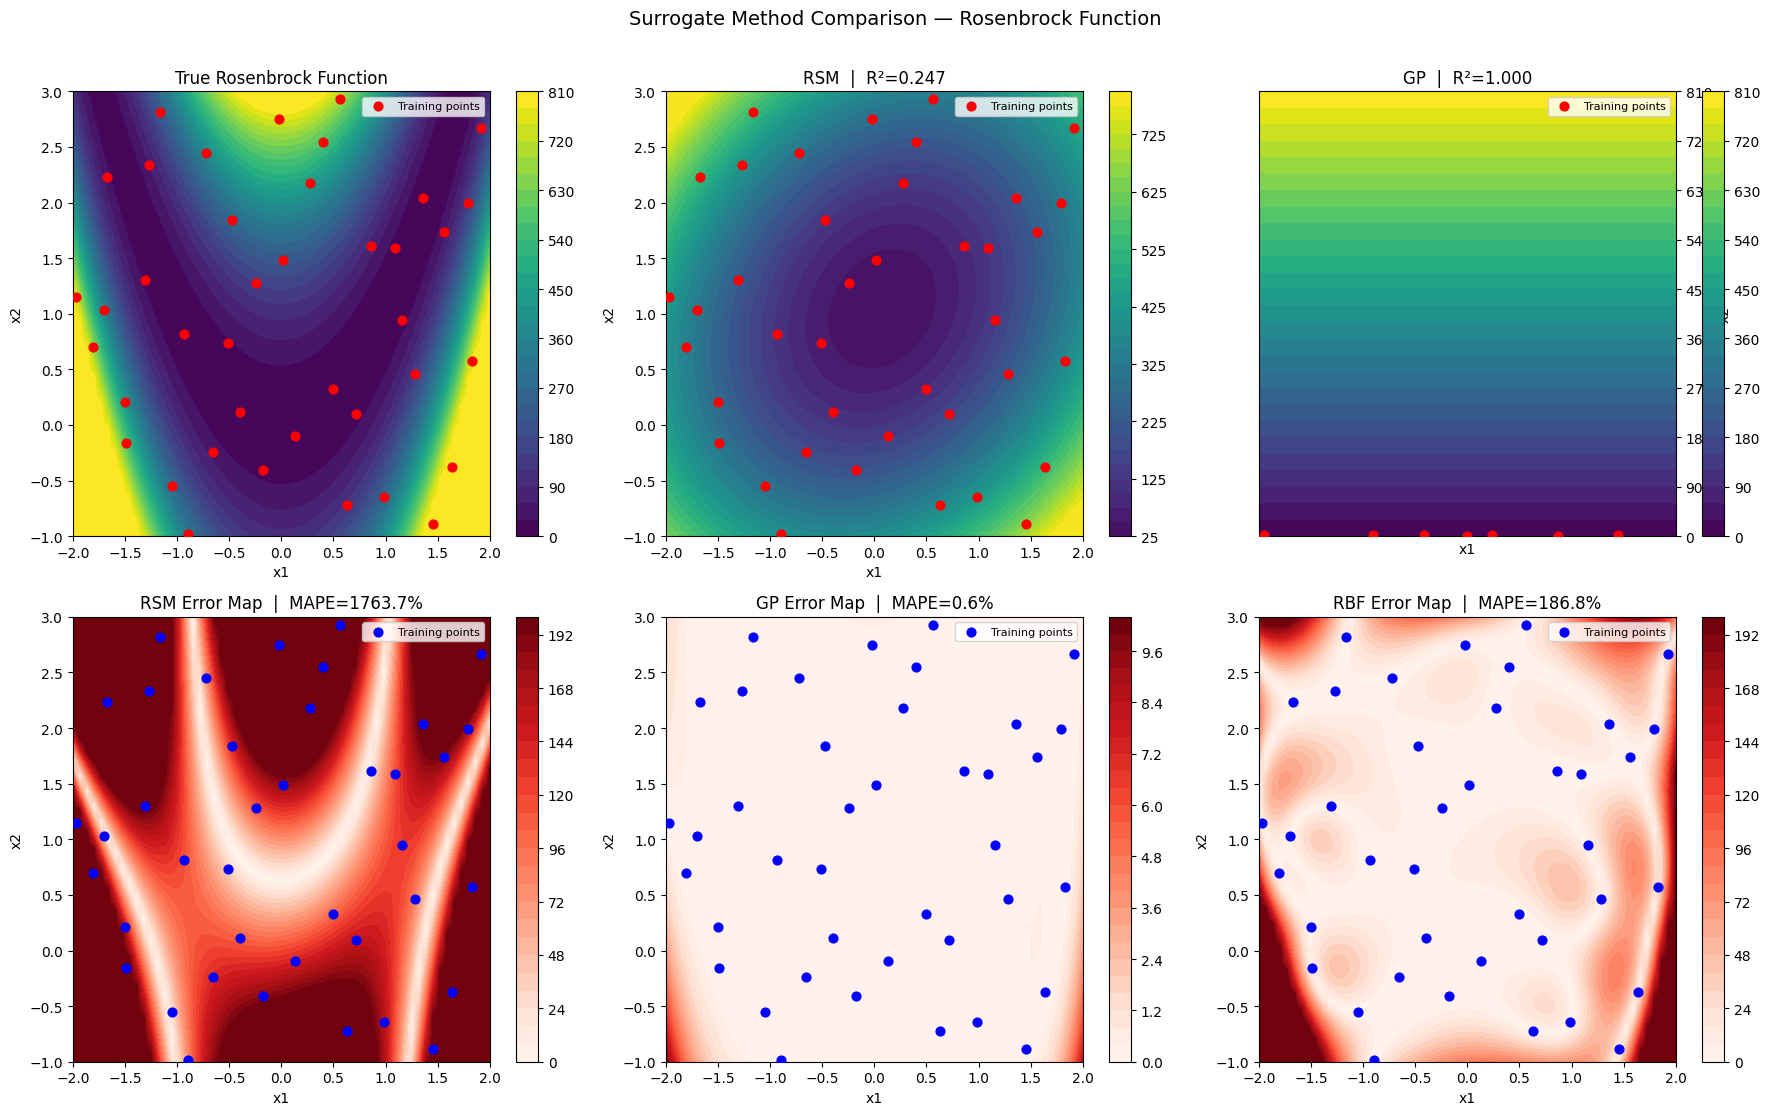

In [19]:
# Build a fine grid for visualization
n_grid = 60
x1_grid = np.linspace(-2, 2, n_grid)
x2_grid = np.linspace(-1, 3, n_grid)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack([X1.ravel(), X2.ravel()])

# True function on grid
Y_true = np.array([rosenbrock(X_grid[i,0], X_grid[i,1])
                   for i in range(len(X_grid))]).reshape(n_grid, n_grid)

# RSM prediction on grid
X_grid_scaled = scaler.transform(X_grid)
X_grid_poly   = poly.transform(X_grid_scaled)
Y_rsm = rsm.predict(X_grid_poly).reshape(n_grid, n_grid)

# GP prediction on grid
Y_gp, Y_std = gp.predict(X_grid_scaled, return_std=True)
Y_gp  = Y_gp.reshape(n_grid, n_grid)
Y_std = Y_std.reshape(n_grid, n_grid)

# RBF prediction on grid
Y_rbf = rbf(X_grid[:,0], X_grid[:,1]).reshape(n_grid, n_grid)

# Shared color scale so all plots are comparable
vmin = 0
vmax = 800

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Row 1: Surrogate predictions
plots = [
    (axes[0,0], Y_true, 'True Rosenbrock Function'),
    (axes[0,1], Y_rsm,  f'RSM  |  R²={metrics["RSM"]["r2"]:.3f}'),
    (axes[0,2], Y_gp,   f'GP   |  R²={metrics["GP"]["r2"]:.3f}'),
]
for ax, Y, title in plots:
    im = ax.contourf(X1, X2, np.clip(Y, vmin, vmax),
                     levels=30, cmap='viridis',
                     vmin=vmin, vmax=vmax)
    ax.scatter(X_train[:,0], X_train[:,1],
               c='red', s=40, zorder=5, label='Training points')
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.legend(fontsize=8)

# RBF in its own spot
im = axes[0,2].contourf(X1, X2, np.clip(Y_gp, vmin, vmax),
                         levels=30, cmap='viridis',
                         vmin=vmin, vmax=vmax)

# Row 2: Error maps
for ax, Y, name in [
    (axes[1,0], Y_rsm, 'RSM'),
    (axes[1,1], Y_gp,  'GP'),
    (axes[1,2], Y_rbf, 'RBF')
]:
    err = np.abs(Y - Y_true)
    im2 = ax.contourf(X1, X2, np.clip(err, 0, 200),
                      levels=30, cmap='Reds')
    ax.scatter(X_train[:,0], X_train[:,1],
               c='blue', s=40, zorder=5, label='Training points')
    plt.colorbar(im2, ax=ax)
    r2  = metrics[name]['r2']
    mape = metrics[name]['mape']
    ax.set_title(f'{name} Error Map  |  MAPE={mape:.1f}%')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.legend(fontsize=8)

# RBF prediction plot (missing from row 1)
axes[0,2].cla()
im = axes[0,2].contourf(X1, X2, np.clip(Y_gp, vmin, vmax),
                         levels=30, cmap='viridis',
                         vmin=vmin, vmax=vmax)
axes[0,2].scatter(X_train[:,0], X_train[:,1],
                   c='red', s=40, zorder=5, label='Training points')
plt.colorbar(im, axes[0,2])
axes[0,2].set_title(f'GP  |  R²={metrics["GP"]["r2"]:.3f}')
axes[0,2].set_xlabel('x1')
axes[0,2].set_ylabel('x2')
axes[0,2].legend(fontsize=8)

plt.suptitle('Surrogate Method Comparison — Rosenbrock Function',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/surrogate_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

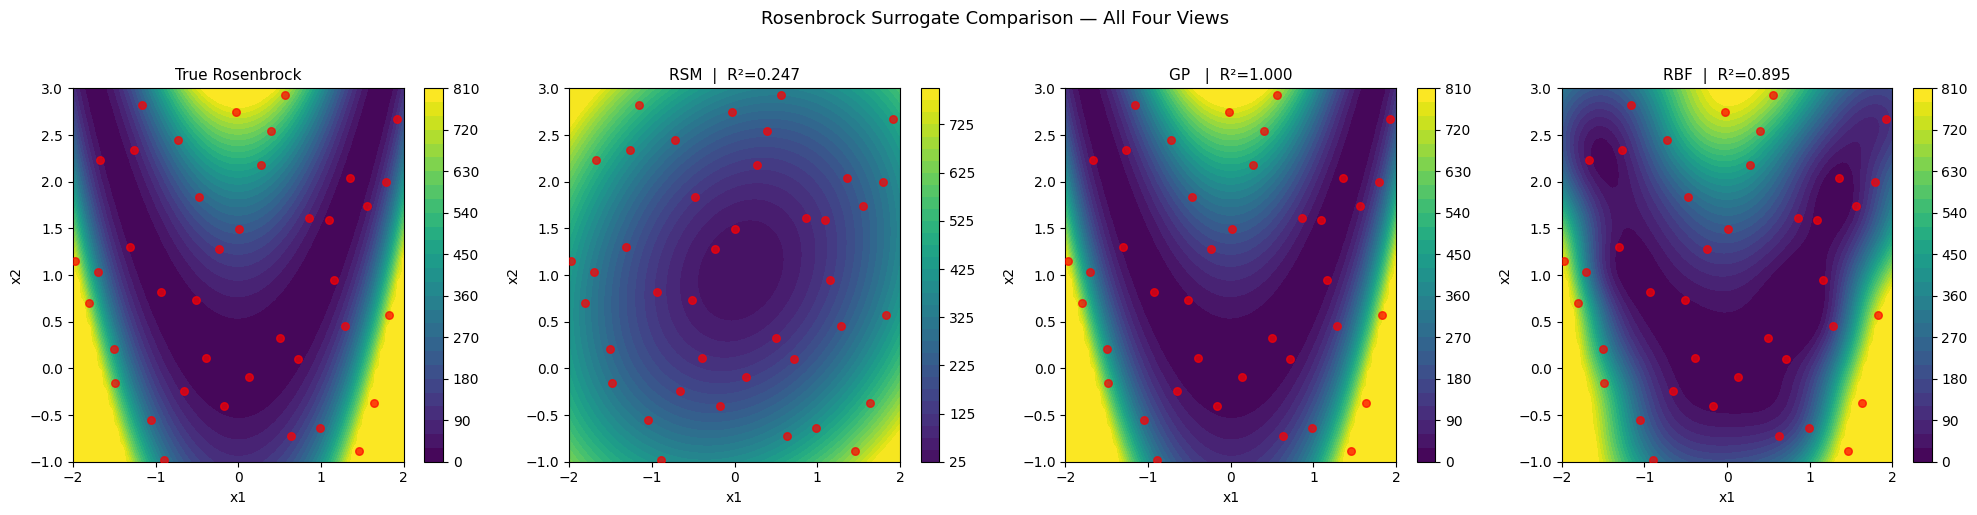


Final verdict:
  RSM : Fast (0.0036s) but failed — R²=0.247
  GP  : Slower (0.1457s) but near-perfect — R²=1.000
  RBF : Fast (0.0016s) and decent — R²=0.895

For nonlinear problems with limited data, GP wins.
RSM only works when the response is nearly quadratic.
RBF is a reasonable middle ground when GP is too slow.


In [20]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

titles = [
    'True Rosenbrock',
    f'RSM  |  R²={metrics["RSM"]["r2"]:.3f}',
    f'GP   |  R²={metrics["GP"]["r2"]:.3f}',
    f'RBF  |  R²={metrics["RBF"]["r2"]:.3f}'
]
surfaces = [Y_true, Y_rsm, Y_gp, Y_rbf]

for ax, Y, title in zip(axes, surfaces, titles):
    im = ax.contourf(X1, X2, np.clip(Y, 0, 800),
                     levels=30, cmap='viridis',
                     vmin=0, vmax=800)
    ax.scatter(X_train[:,0], X_train[:,1],
               c='red', s=30, zorder=5, alpha=0.7)
    plt.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

plt.suptitle('Rosenbrock Surrogate Comparison — All Four Views',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/surrogate_comparison_clean.png',
            dpi=150, bbox_inches='tight')
plt.show()

print()
print("Final verdict:")
print(f"  RSM : Fast ({metrics['RSM']['train_time']:.4f}s) but failed — R²={metrics['RSM']['r2']:.3f}")
print(f"  GP  : Slower ({metrics['GP']['train_time']:.4f}s) but near-perfect — R²={metrics['GP']['r2']:.3f}")
print(f"  RBF : Fast ({metrics['RBF']['train_time']:.4f}s) and decent — R²={metrics['RBF']['r2']:.3f}")
print()
print("For nonlinear problems with limited data, GP wins.")
print("RSM only works when the response is nearly quadratic.")
print("RBF is a reasonable middle ground when GP is too slow.")